# DINOv3 Feature Clustering for BIM Objects

KMeans clustering on DINOv3 embeddings (1024-dim) from rendered views.
Compare **colored** vs **colorless** renders, with PCA reduction and handcrafted feature fusion.

All evaluation uses **19 merged types**.

In [1]:
import sys, json, warnings
sys.path.insert(0, '..')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import trimesh
from pathlib import Path
from scipy.stats import entropy
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
warnings.filterwarnings('ignore')
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
# Load dataset + DINO features + handcrafted features
df_all = pd.read_parquet('../../processed_data/features/train_features.parquet')
with open('../../data/annotated_subset.json') as f:
    annotated = json.load(f)
annotated_gids = set(d['GlobalId'] for d in annotated)
df = df_all[df_all['GlobalId'].isin(annotated_gids)].copy().reset_index(drop=True)

colored_dir = Path('../../processed_data/rendered_features/dinov3/colored')
colorless_dir = Path('../../processed_data/rendered_features/dinov3/colorless')
mesh_dir = Path('../../processed_data/meshes/train')

def load_dino_features(feat_dir, gids):
    features, matched_gids = [], []
    for gid in gids:
        path = feat_dir / f'{gid}.npy'
        if path.exists():
            features.append(np.load(path))
            matched_gids.append(gid)
    return np.stack(features), matched_gids

X_colored, gids_colored = load_dino_features(colored_dir, df['GlobalId'].values)
X_colorless, gids_colorless = load_dino_features(colorless_dir, df['GlobalId'].values)

# Keep only objects present in both
gids_both = sorted(set(gids_colored) & set(gids_colorless))
df_dino = df[df['GlobalId'].isin(gids_both)].copy().reset_index(drop=True)
idx_c = {g: i for i, g in enumerate(gids_colored)}
idx_cl = {g: i for i, g in enumerate(gids_colorless)}
X_colored = np.stack([X_colored[idx_c[g]] for g in df_dino['GlobalId']])
X_colorless = np.stack([X_colorless[idx_cl[g]] for g in df_dino['GlobalId']])

# Compute handcrafted 9 features
BASELINE = ['Length', 'CrossSectionArea', 'Volume', 'NumVertices']
Z_AXIS = np.array([0, 0, 1])
ref_dirs = np.array(trimesh.creation.icosphere(subdivisions=1).vertices)
ref_dirs = ref_dirs / np.linalg.norm(ref_dirs, axis=1, keepdims=True)
N_BINS = len(ref_dirs)

engineered = []
for gid in df_dino['GlobalId'].values:
    mesh_path = mesh_dir / f'{gid}.obj'
    if not mesh_path.exists():
        engineered.append(None); continue
    mesh = trimesh.load(mesh_path, force='mesh', process=False)
    verts = np.array(mesh.vertices)
    if len(verts) < 3:
        engineered.append(None); continue
    pca = PCA(n_components=3).fit(verts)
    pc1_z = abs(np.dot(pca.components_[0], Z_AXIS))
    pc3_z = abs(np.dot(pca.components_[2], Z_AXIS))
    extents = np.sqrt(pca.explained_variance_)
    cs_ratio = extents[2] / extents[1] if extents[1] > 1e-8 else 0.0
    normals, areas = mesh.face_normals, mesh.area_faces
    if len(normals) > 0 and len(areas) > 0:
        dots = normals @ ref_dirs.T
        hist = np.bincount(dots.argmax(axis=1), weights=areas, minlength=N_BINS)
        hist = hist / hist.sum()
        norm_ent = entropy(hist) / np.log(N_BINS)
        horiz_frac = areas[np.abs(normals @ Z_AXIS) > 0.9].sum() / areas.sum()
    else:
        norm_ent, horiz_frac = 0.0, 0.0
    engineered.append({'pc1_z': pc1_z, 'pc3_z': pc3_z, 'cs_aspect_ratio': cs_ratio,
                       'normal_entropy': norm_ent, 'horiz_frac': horiz_frac})

valid_mask = np.array([e is not None for e in engineered])
df_valid = df_dino[valid_mask].reset_index(drop=True)
X_colored = X_colored[valid_mask]
X_colorless = X_colorless[valid_mask]
df_eng = pd.DataFrame([e for e in engineered if e is not None])
X_handcrafted = np.hstack([
    np.log1p(df_valid[BASELINE].clip(lower=0).values),
    df_eng[['pc1_z', 'pc3_z', 'cs_aspect_ratio', 'normal_entropy', 'horiz_frac']].values
])

# Merge types (24 → 19)
TYPE_MAP = {
    'IfcWall': 'Wall', 'IfcWallStandardCase': 'Wall',
    'IfcFurniture': 'Furniture', 'IfcFurnishingElement': 'Furniture',
    'IfcSystemFurnitureElement': 'Furniture',
    'IfcDistributionFlowElement': 'MEP', 'IfcFlowTerminal': 'MEP',
    'IfcStair': 'Stair', 'IfcStairFlight': 'Stair',
}
ifc_types = np.array([TYPE_MAP.get(t, t) for t in df_valid['IfcType'].values])

print(f'{len(df_valid)} objects, {len(set(ifc_types))} merged types')
print(f'Colored: {X_colored.shape}, Colorless: {X_colorless.shape}, Handcrafted: {X_handcrafted.shape}')

1845 objects, 19 merged types
Colored: (1845, 1024), Colorless: (1845, 1024), Handcrafted: (1845, 9)


In [3]:
SEEDS = list(range(42, 52))
PCA_DIMS = [2, 4, 8, 16, 32]
K_VALUES = [4, 8, 16, 24, 32]

def compute_purity(labels, true_labels):
    return sum(pd.Series(true_labels[labels == c]).value_counts().iloc[0]
               for c in np.unique(labels)) / len(labels)

def eval_kmeans(X, labels, k=24, seeds=SEEDS, scale=True):
    if scale:
        X = RobustScaler().fit_transform(X)
    metrics = {'purity': [], 'silhouette': [], 'davies_bouldin': [], 'calinski_harabasz': []}
    for s in seeds:
        lab = MiniBatchKMeans(k, batch_size=1024, n_init='auto', random_state=s).fit_predict(X)
        metrics['purity'].append(compute_purity(lab, labels))
        metrics['silhouette'].append(silhouette_score(X, lab))
        metrics['davies_bouldin'].append(davies_bouldin_score(X, lab))
        metrics['calinski_harabasz'].append(calinski_harabasz_score(X, lab))
    return {k_: (np.mean(v), np.std(v)) for k_, v in metrics.items()}

def per_type_purity(lab, true_labels):
    cluster_dominant = {}
    for c in np.unique(lab):
        mask = lab == c
        counts = pd.Series(true_labels[mask]).value_counts()
        cluster_dominant[c] = counts.index[0]
    type_purity = {}
    for t in np.unique(true_labels):
        t_mask = true_labels == t
        t_objects = t_mask.sum()
        correct = sum(1 for i in np.where(t_mask)[0] if cluster_dominant[lab[i]] == t)
        type_purity[t] = correct / t_objects
    return type_purity

def title_metrics(X, lab, labels):
    p = compute_purity(lab, labels)
    s = silhouette_score(X, lab)
    db = davies_bouldin_score(X, lab)
    return f'Purity={p:.3f}  Sil={s:.3f}  DB={db:.2f}'

# Precompute PCA projections
pca_colored, pca_colorless = {}, {}
for d in PCA_DIMS:
    pca_colored[d] = PCA(n_components=d, random_state=42).fit_transform(X_colored)
    pca_colorless[d] = PCA(n_components=d, random_state=42).fit_transform(X_colorless)
pca_colored[1024] = X_colored
pca_colorless[1024] = X_colorless
all_dims = PCA_DIMS + [1024]

print('Ready. PCA variance retained (colored):')
for d in PCA_DIMS:
    pca_obj = PCA(n_components=d, random_state=42).fit(X_colored)
    print(f'  PCA-{d}: {pca_obj.explained_variance_ratio_.sum():.1%}')

Ready. PCA variance retained (colored):
  PCA-2: 31.7%
  PCA-4: 45.9%
  PCA-8: 59.6%
  PCA-16: 70.9%
  PCA-32: 81.2%


## 1. PCA × k Purity Grid (DINO only)

In [4]:
# Sweep PCA dims × k for colored, colorless, and handcrafted baseline
dim_labels = [str(d) for d in all_dims]

grid_colored = np.zeros((len(all_dims), len(K_VALUES)))
grid_colorless = np.zeros((len(all_dims), len(K_VALUES)))
for i, d in enumerate(all_dims):
    for j, k in enumerate(K_VALUES):
        grid_colored[i, j] = eval_kmeans(pca_colored[d], ifc_types, k=k)['purity'][0]
        grid_colorless[i, j] = eval_kmeans(pca_colorless[d], ifc_types, k=k)['purity'][0]
        print(f'  PCA-{d:>4} k={k:>2}  col={grid_colored[i,j]:.3f}  cl={grid_colorless[i,j]:.3f}')

hc_purity = {k: eval_kmeans(X_handcrafted, ifc_types, k=k)['purity'][0] for k in K_VALUES}
print(f'\nHandcrafted: {" ".join(f"k={k}:{v:.3f}" for k,v in hc_purity.items())}')

  PCA-   2 k= 4  col=0.287  cl=0.291
  PCA-   2 k= 8  col=0.322  cl=0.331
  PCA-   2 k=16  col=0.383  cl=0.393
  PCA-   2 k=24  col=0.422  cl=0.437
  PCA-   2 k=32  col=0.454  cl=0.463
  PCA-   4 k= 4  col=0.275  cl=0.280
  PCA-   4 k= 8  col=0.334  cl=0.337
  PCA-   4 k=16  col=0.410  cl=0.414
  PCA-   4 k=24  col=0.452  cl=0.456
  PCA-   4 k=32  col=0.492  cl=0.485
  PCA-   8 k= 4  col=0.271  cl=0.281
  PCA-   8 k= 8  col=0.389  cl=0.400
  PCA-   8 k=16  col=0.496  cl=0.488
  PCA-   8 k=24  col=0.552  cl=0.540
  PCA-   8 k=32  col=0.579  cl=0.571
  PCA-  16 k= 4  col=0.220  cl=0.221
  PCA-  16 k= 8  col=0.333  cl=0.331
  PCA-  16 k=16  col=0.487  cl=0.493
  PCA-  16 k=24  col=0.561  cl=0.567
  PCA-  16 k=32  col=0.608  cl=0.608
  PCA-  32 k= 4  col=0.191  cl=0.184
  PCA-  32 k= 8  col=0.285  cl=0.280
  PCA-  32 k=16  col=0.423  cl=0.407
  PCA-  32 k=24  col=0.501  cl=0.508
  PCA-  32 k=32  col=0.571  cl=0.566
  PCA-1024 k= 4  col=0.295  cl=0.298
  PCA-1024 k= 8  col=0.396  cl=0.388
 

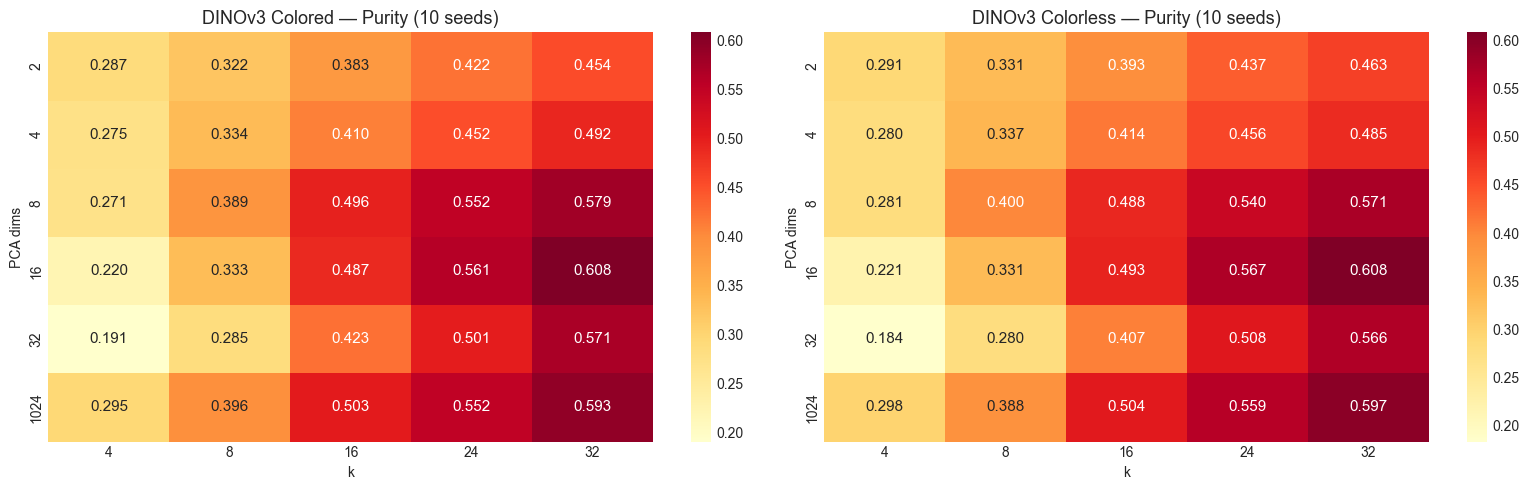

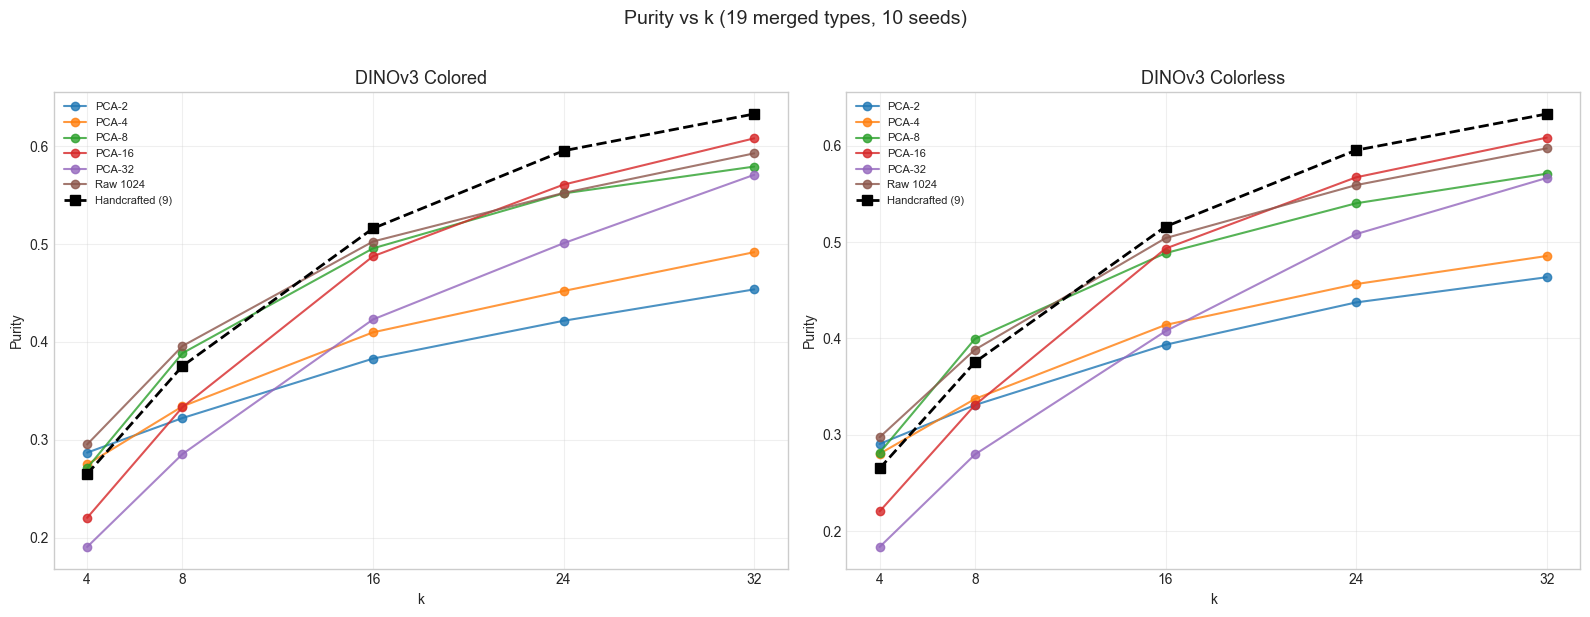

In [5]:
# Heatmaps: PCA × k
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, grid, title in [(axes[0], grid_colored, 'Colored'), (axes[1], grid_colorless, 'Colorless')]:
    sns.heatmap(grid, annot=True, fmt='.3f', cmap='YlOrRd',
                xticklabels=[str(k) for k in K_VALUES], yticklabels=dim_labels,
                ax=ax, annot_kws={'size': 11})
    ax.set_xlabel('k'); ax.set_ylabel('PCA dims')
    ax.set_title(f'DINOv3 {title} — Purity (10 seeds)', fontsize=13)
plt.tight_layout(); plt.show()

# Line plot: purity vs k
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, grid, title in [(axes[0], grid_colored, 'Colored'), (axes[1], grid_colorless, 'Colorless')]:
    for i, d in enumerate(all_dims):
        label = f'PCA-{d}' if d != 1024 else 'Raw 1024'
        ax.plot(K_VALUES, grid[i], 'o-', label=label, alpha=0.8)
    ax.plot(K_VALUES, [hc_purity[k] for k in K_VALUES], 's--', color='black',
            linewidth=2, markersize=7, label='Handcrafted (9)')
    ax.set_xlabel('k'); ax.set_ylabel('Purity')
    ax.set_title(f'DINOv3 {title}', fontsize=13)
    ax.legend(fontsize=8); ax.set_xticks(K_VALUES); ax.grid(True, alpha=0.3)
plt.suptitle('Purity vs k (19 merged types, 10 seeds)', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

## 2. Best PCA Config — Cluster–Type Heatmaps

Colored: best PCA-16, k=32 → purity=0.608


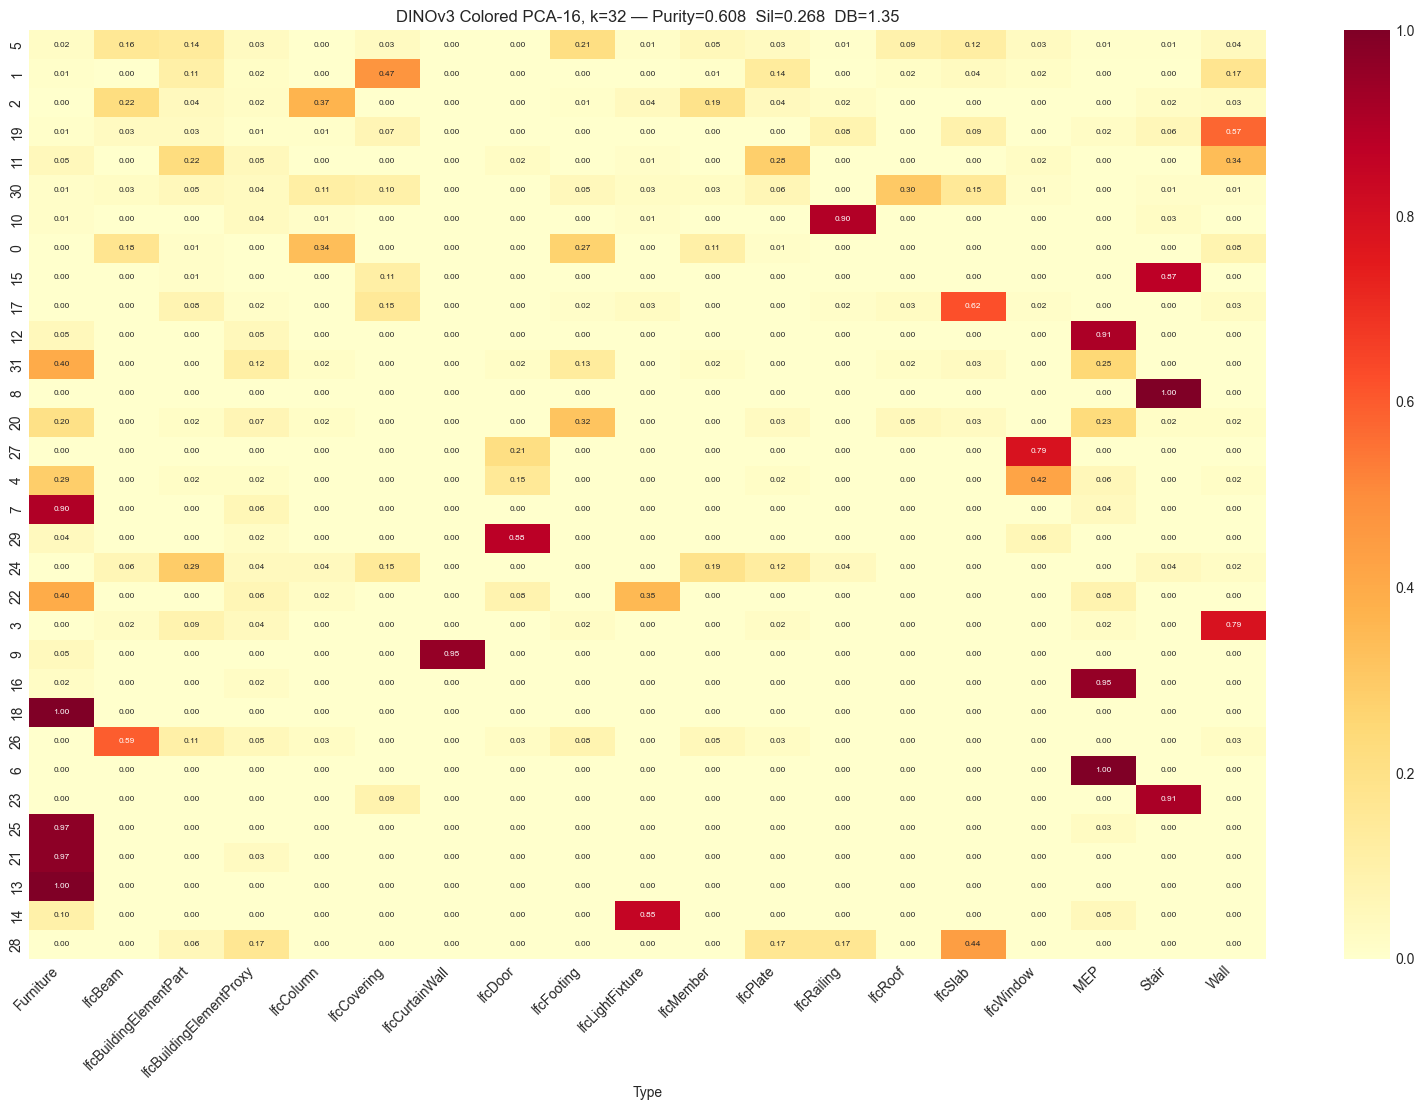

Colorless: best PCA-16, k=32 → purity=0.608


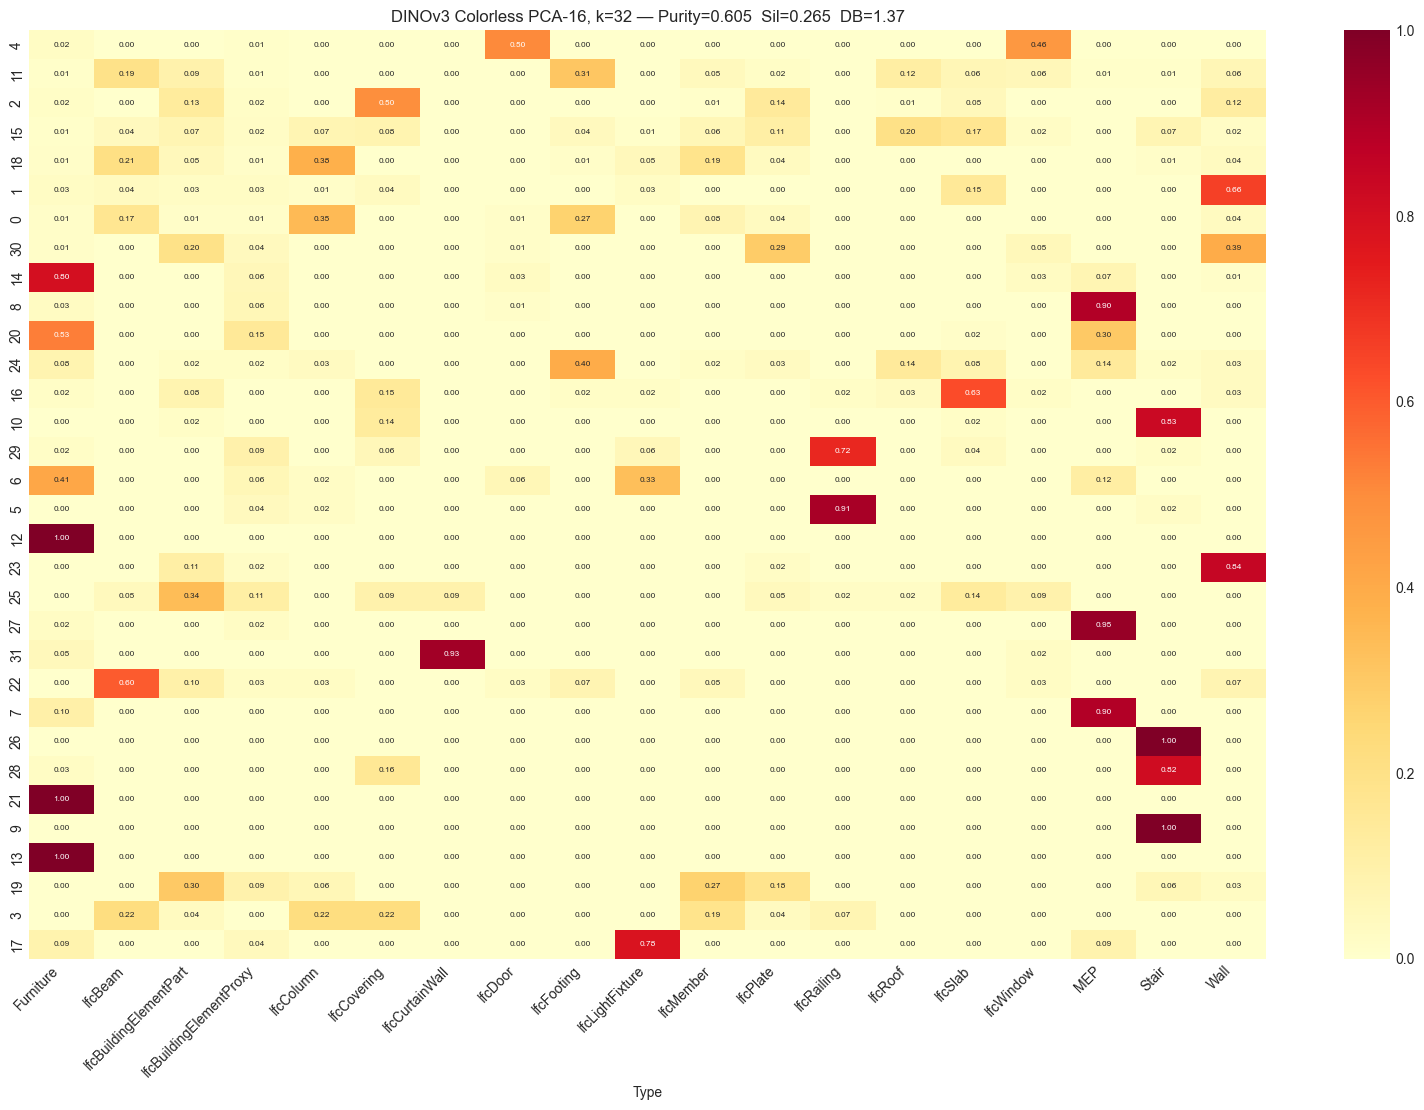

In [6]:
# Best (dim, k) per variant — heatmaps
for grid, pca_dict, label in [
    (grid_colored, pca_colored, 'Colored'),
    (grid_colorless, pca_colorless, 'Colorless'),
]:
    best_idx = np.unravel_index(grid.argmax(), grid.shape)
    best_dim, best_k = all_dims[best_idx[0]], K_VALUES[best_idx[1]]
    print(f'{label}: best PCA-{best_dim}, k={best_k} → purity={grid[best_idx]:.3f}')

    X_sc = RobustScaler().fit_transform(pca_dict[best_dim])
    lab = MiniBatchKMeans(best_k, batch_size=1024, n_init='auto', random_state=42).fit_predict(X_sc)
    ct = pd.crosstab(pd.Series(lab, name='Cluster'),
                     pd.Series(ifc_types, name='Type'), normalize='index')
    ct = ct.reindex(pd.Series(lab).value_counts().index)

    fig, ax = plt.subplots(figsize=(16, max(8, best_k * 0.35)))
    sns.heatmap(ct, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax, annot_kws={'size': 6})
    ax.set_title(f'DINOv3 {label} PCA-{best_dim}, k={best_k} — {title_metrics(X_sc, lab, ifc_types)}', fontsize=12)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    plt.tight_layout(); plt.show()

## 3. DINO PCA + Handcrafted Fusion — All Combos

In [7]:
# PCA × k grid for DINO + Handcrafted fusion
grid_col_hc = np.zeros((len(all_dims), len(K_VALUES)))
grid_cl_hc = np.zeros((len(all_dims), len(K_VALUES)))
for i, d in enumerate(all_dims):
    X_fused_c = np.hstack([pca_colored[d], X_handcrafted])
    X_fused_cl = np.hstack([pca_colorless[d], X_handcrafted])
    for j, k in enumerate(K_VALUES):
        grid_col_hc[i, j] = eval_kmeans(X_fused_c, ifc_types, k=k)['purity'][0]
        grid_cl_hc[i, j] = eval_kmeans(X_fused_cl, ifc_types, k=k)['purity'][0]
        print(f'  PCA-{d:>4}+HC k={k:>2}  col={grid_col_hc[i,j]:.3f}  cl={grid_cl_hc[i,j]:.3f}')

  PCA-   2+HC k= 4  col=0.284  cl=0.284
  PCA-   2+HC k= 8  col=0.386  cl=0.386
  PCA-   2+HC k=16  col=0.537  cl=0.526
  PCA-   2+HC k=24  col=0.608  cl=0.606
  PCA-   2+HC k=32  col=0.651  cl=0.654
  PCA-   4+HC k= 4  col=0.278  cl=0.285
  PCA-   4+HC k= 8  col=0.383  cl=0.365
  PCA-   4+HC k=16  col=0.512  cl=0.519
  PCA-   4+HC k=24  col=0.579  cl=0.575
  PCA-   4+HC k=32  col=0.616  cl=0.612
  PCA-   8+HC k= 4  col=0.275  cl=0.274
  PCA-   8+HC k= 8  col=0.409  cl=0.416
  PCA-   8+HC k=16  col=0.563  cl=0.556
  PCA-   8+HC k=24  col=0.632  cl=0.612
  PCA-   8+HC k=32  col=0.658  cl=0.648
  PCA-  16+HC k= 4  col=0.255  cl=0.255
  PCA-  16+HC k= 8  col=0.376  cl=0.393
  PCA-  16+HC k=16  col=0.538  cl=0.544
  PCA-  16+HC k=24  col=0.622  cl=0.602
  PCA-  16+HC k=32  col=0.646  cl=0.638
  PCA-  32+HC k= 4  col=0.256  cl=0.246
  PCA-  32+HC k= 8  col=0.336  cl=0.341
  PCA-  32+HC k=16  col=0.473  cl=0.478
  PCA-  32+HC k=24  col=0.573  cl=0.563
  PCA-  32+HC k=32  col=0.613  cl=0.618


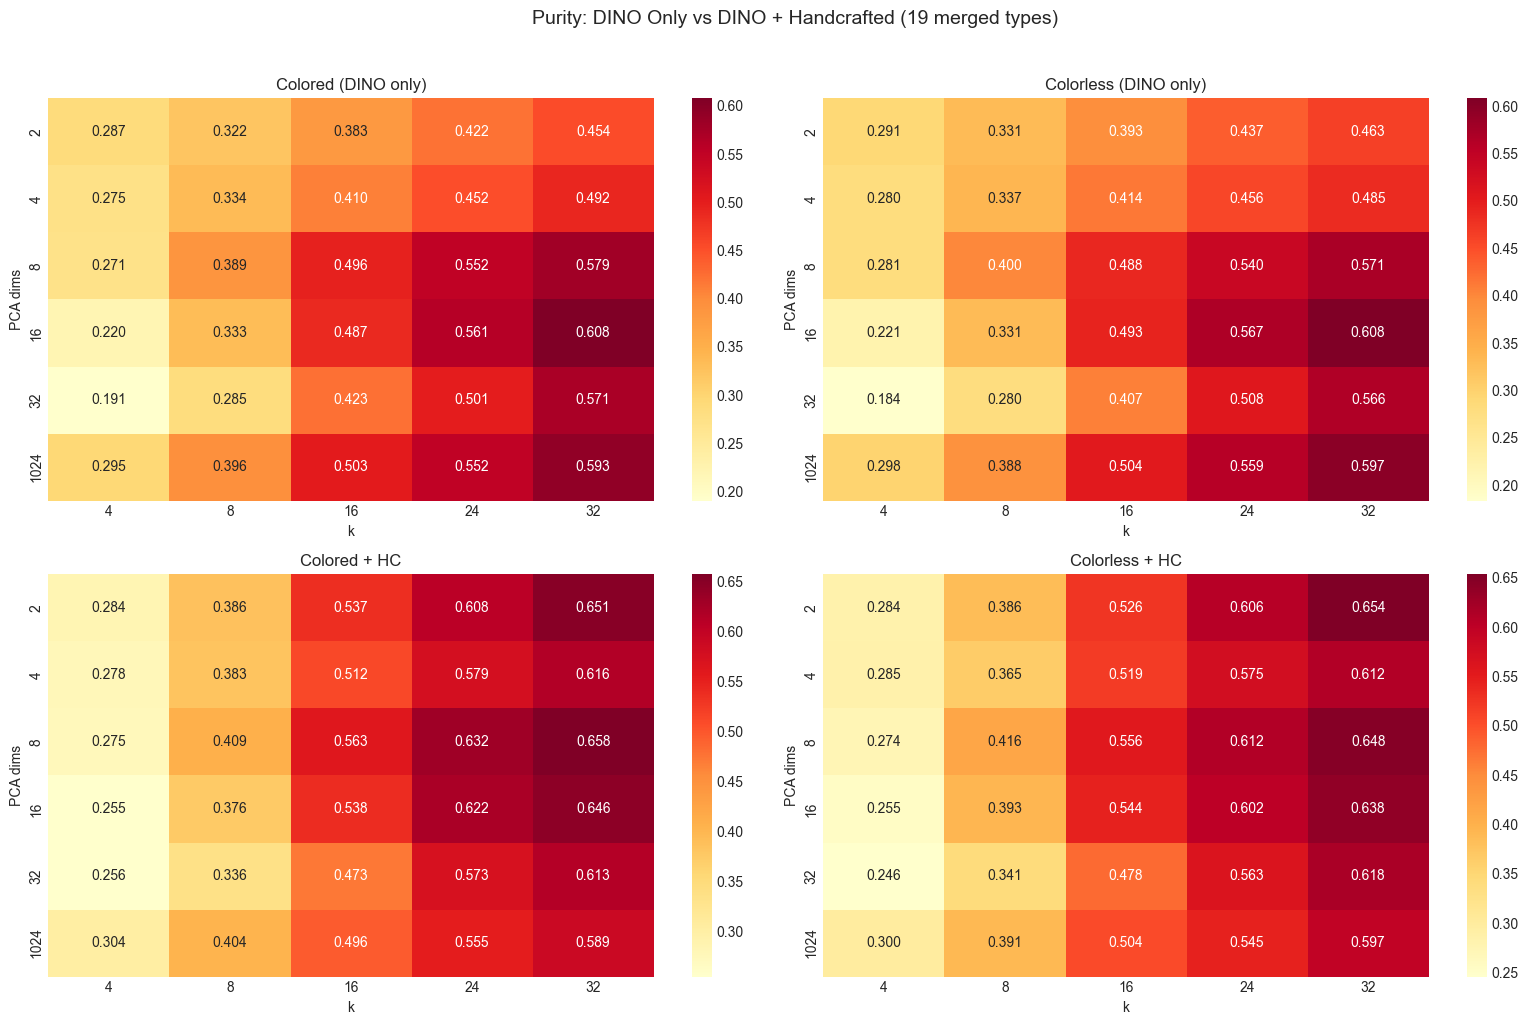

In [8]:
# Heatmaps: DINO-only vs DINO+HC (4 panels)
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
grids = [(grid_colored, 'Colored (DINO only)'), (grid_colorless, 'Colorless (DINO only)'),
         (grid_col_hc, 'Colored + HC'), (grid_cl_hc, 'Colorless + HC')]
for ax, (grid, title) in zip(axes.flat, grids):
    sns.heatmap(grid, annot=True, fmt='.3f', cmap='YlOrRd',
                xticklabels=[str(k) for k in K_VALUES], yticklabels=dim_labels,
                ax=ax, annot_kws={'size': 10})
    ax.set_xlabel('k'); ax.set_ylabel('PCA dims')
    ax.set_title(title, fontsize=12)
plt.suptitle('Purity: DINO Only vs DINO + Handcrafted (19 merged types)', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

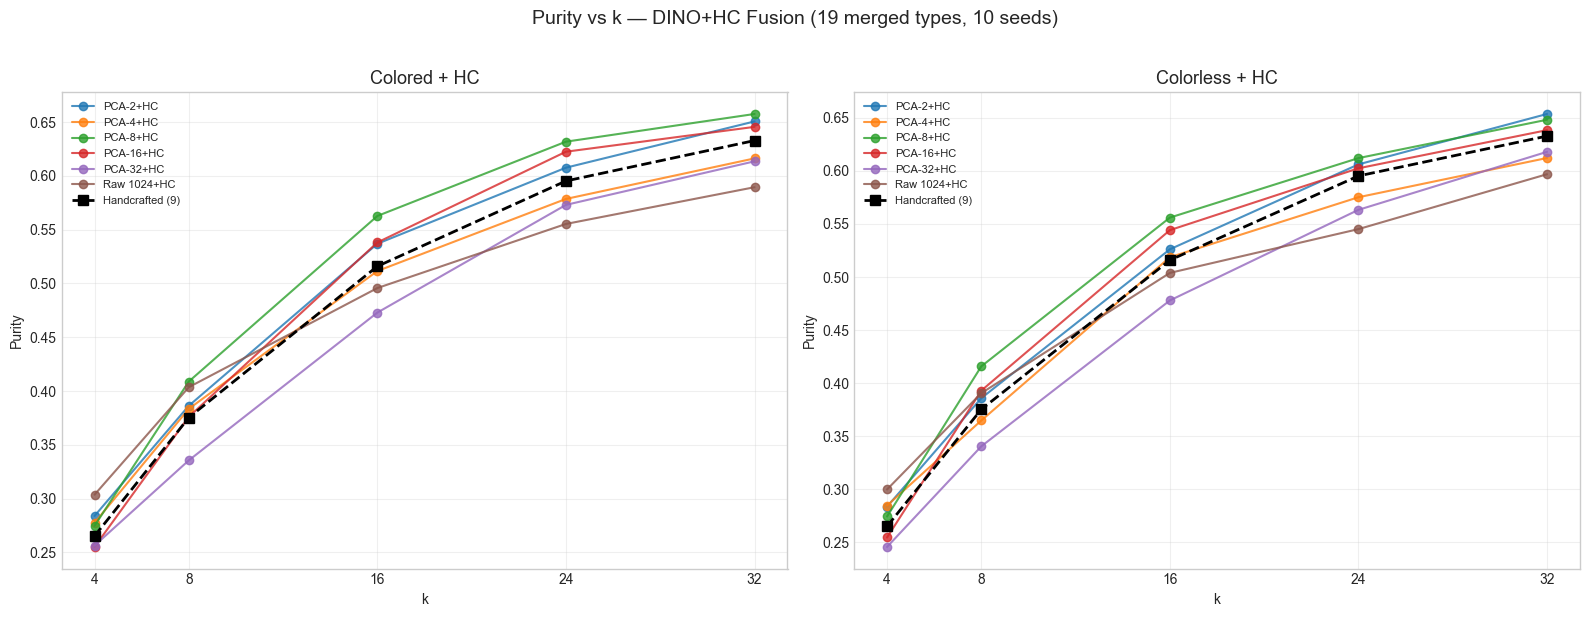

In [9]:
# Line plots: DINO+HC fusion vs handcrafted baseline
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, grid, title in [(axes[0], grid_col_hc, 'Colored + HC'), (axes[1], grid_cl_hc, 'Colorless + HC')]:
    for i, d in enumerate(all_dims):
        label = f'PCA-{d}+HC' if d != 1024 else 'Raw 1024+HC'
        ax.plot(K_VALUES, grid[i], 'o-', label=label, alpha=0.8)
    ax.plot(K_VALUES, [hc_purity[k] for k in K_VALUES], 's--', color='black',
            linewidth=2, markersize=7, label='Handcrafted (9)')
    ax.set_xlabel('k'); ax.set_ylabel('Purity')
    ax.set_title(title, fontsize=13)
    ax.legend(fontsize=8); ax.set_xticks(K_VALUES); ax.grid(True, alpha=0.3)
plt.suptitle('Purity vs k — DINO+HC Fusion (19 merged types, 10 seeds)', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

## 4. Best Overall Config — Detailed Analysis

In [10]:
# Find global best across all 4 grids
all_grids = [
    (grid_colored, pca_colored, 'Colored', False),
    (grid_colorless, pca_colorless, 'Colorless', False),
    (grid_col_hc, pca_colored, 'Colored+HC', True),
    (grid_cl_hc, pca_colorless, 'Colorless+HC', True),
]
# Also handcrafted standalone
best_hc_k = max(hc_purity, key=hc_purity.get)
print(f'Handcrafted best: k={best_hc_k} → purity={hc_purity[best_hc_k]:.3f}\n')

best_configs = []
for grid, pca_dict, label, fused in all_grids:
    idx = np.unravel_index(grid.argmax(), grid.shape)
    d, k = all_dims[idx[0]], K_VALUES[idx[1]]
    X_feat = np.hstack([pca_dict[d], X_handcrafted]) if fused else pca_dict[d]
    best_configs.append((label, d, k, grid[idx], X_feat))
    print(f'{label}: PCA-{d}, k={k} → purity={grid[idx]:.3f} ({X_feat.shape[1]} dims)')

# Sort by purity descending
best_configs.sort(key=lambda x: x[3], reverse=True)
print(f'\nBest overall: {best_configs[0][0]} PCA-{best_configs[0][1]} k={best_configs[0][2]}')

Handcrafted best: k=32 → purity=0.633

Colored: PCA-16, k=32 → purity=0.608 (16 dims)
Colorless: PCA-16, k=32 → purity=0.608 (16 dims)
Colored+HC: PCA-8, k=32 → purity=0.658 (17 dims)
Colorless+HC: PCA-2, k=32 → purity=0.654 (11 dims)

Best overall: Colored+HC PCA-8 k=32


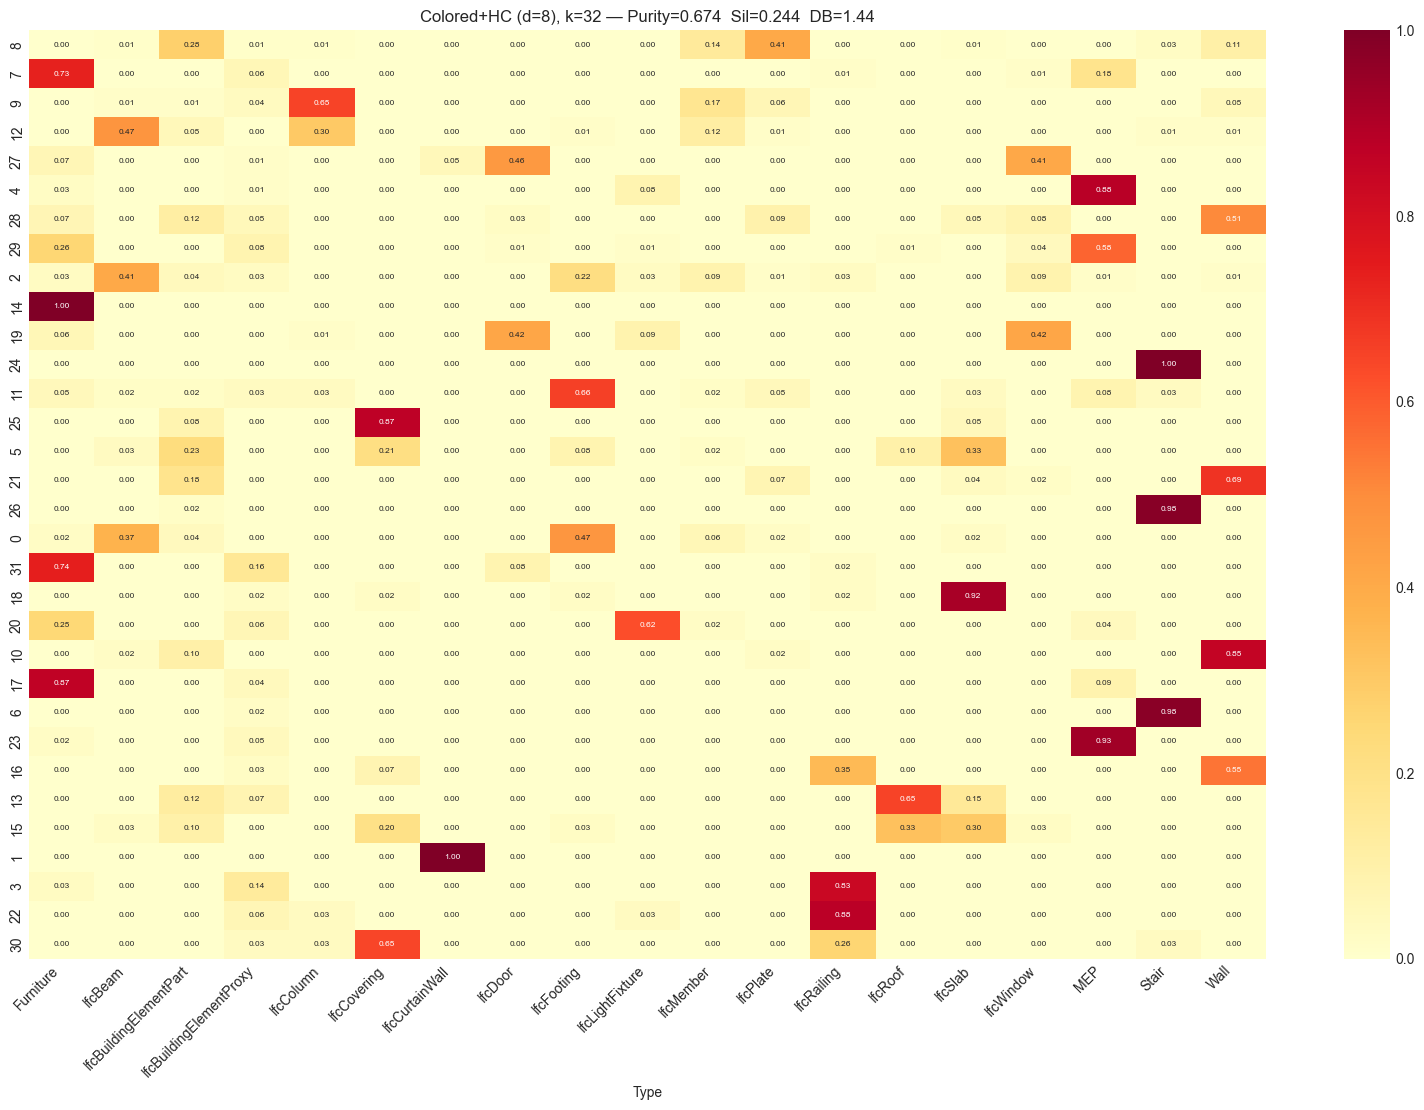

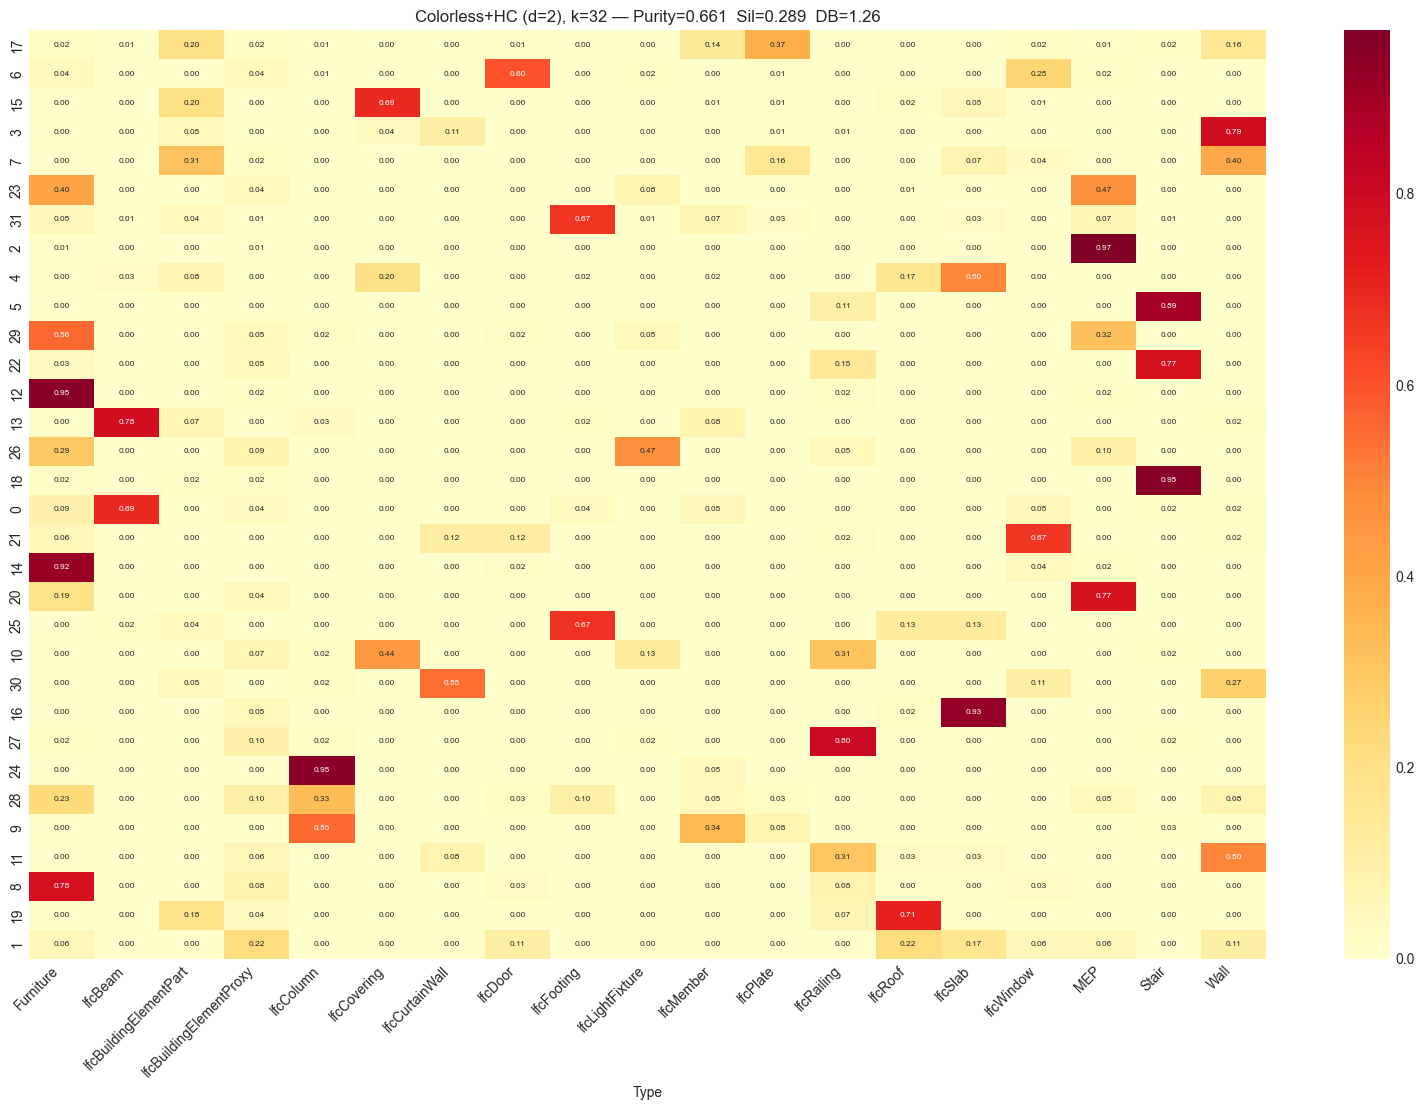

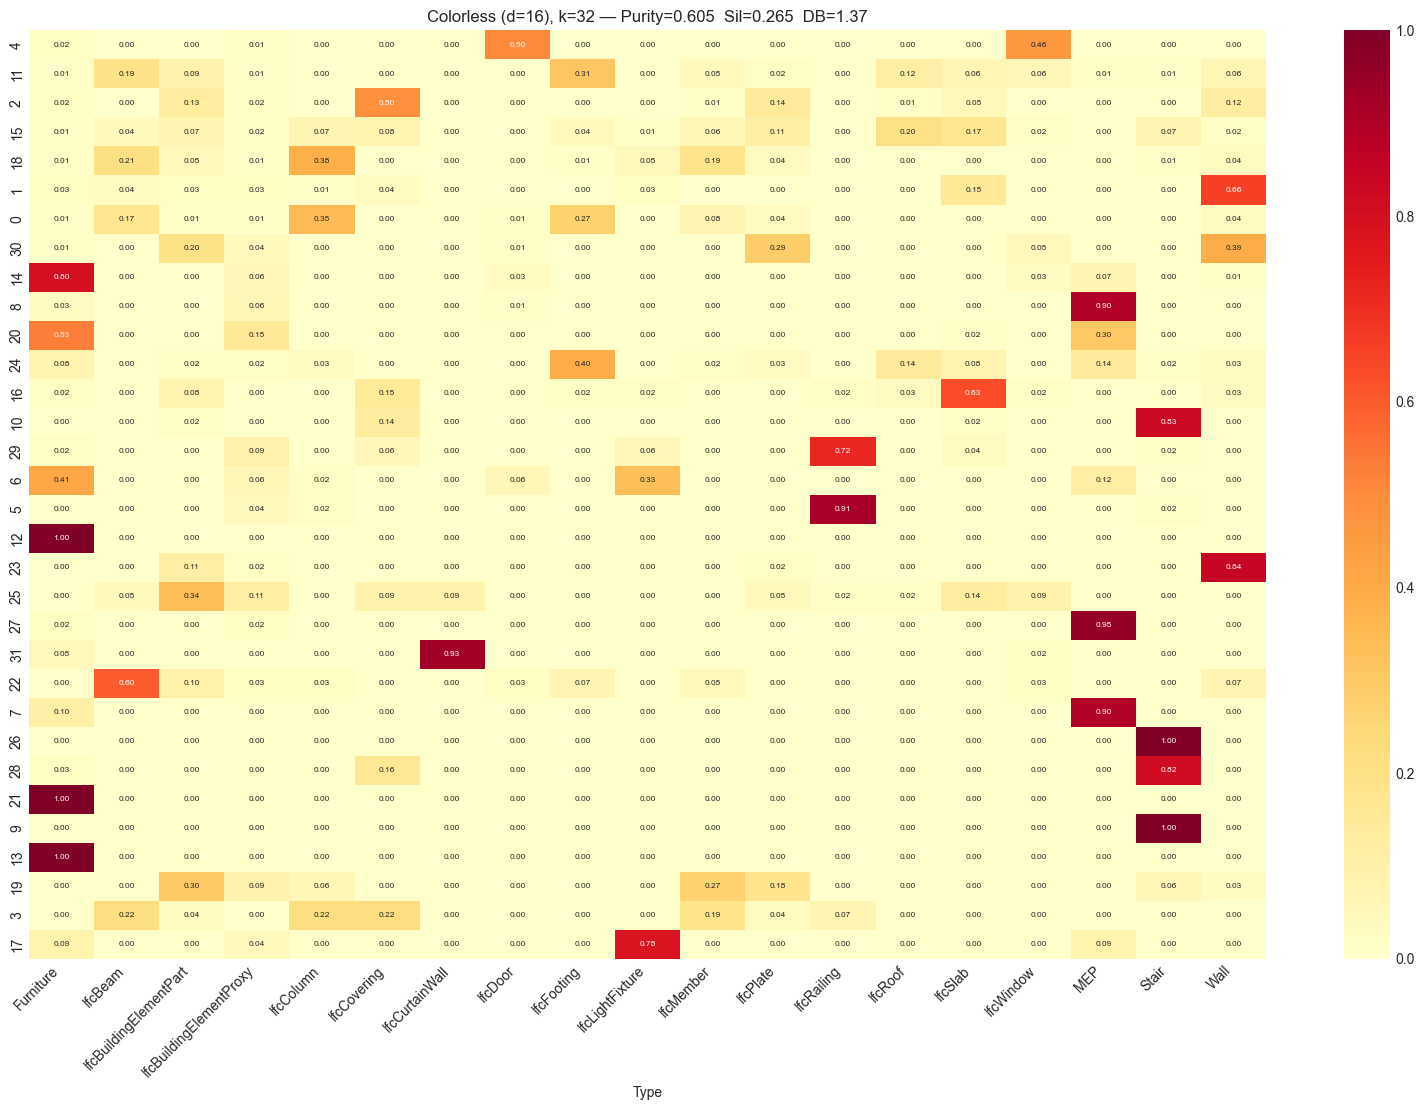

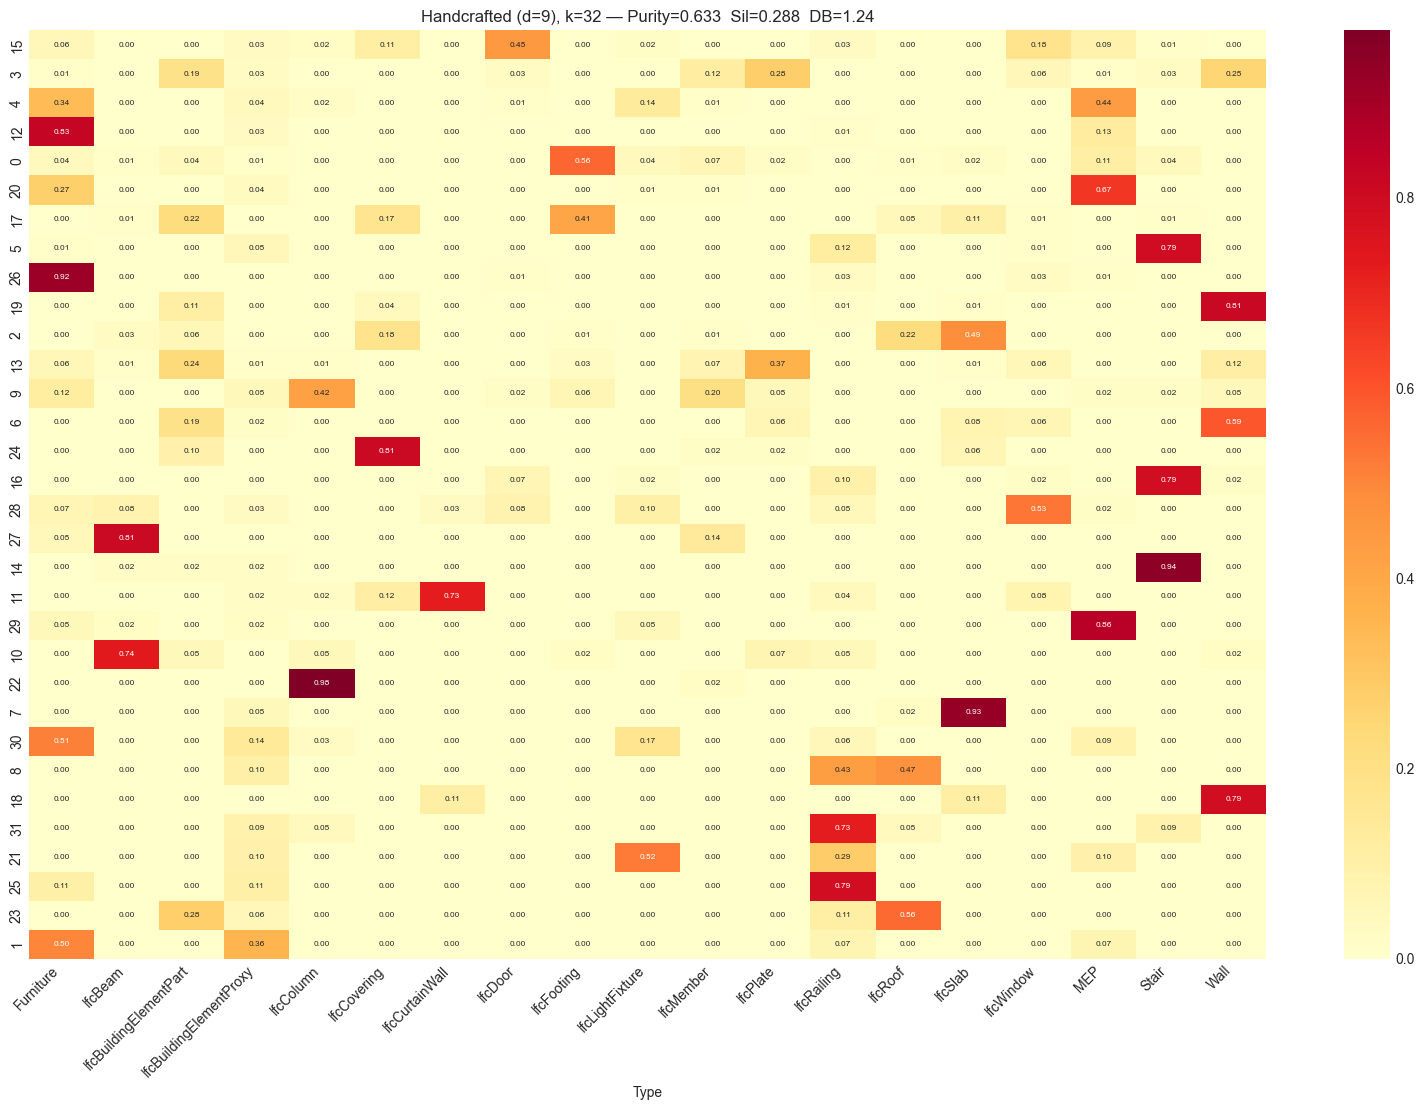

In [12]:
# Cluster–type heatmaps for top configs + handcrafted
plot_configs = best_configs[:3]  # top 3
# Add handcrafted
plot_configs.append(('Handcrafted', 9, best_hc_k, hc_purity[best_hc_k], X_handcrafted))

for label, d, k, pur, X in plot_configs:
    X_sc = RobustScaler().fit_transform(X)
    lab = MiniBatchKMeans(k, batch_size=1024, n_init='auto', random_state=42).fit_predict(X_sc)
    ct = pd.crosstab(pd.Series(lab, name='Cluster'),
                     pd.Series(ifc_types, name='Type'), normalize='index')
    ct = ct.reindex(pd.Series(lab).value_counts().index)

    fig, ax = plt.subplots(figsize=(16, max(8, k * 0.35)))
    sns.heatmap(ct, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax,
                annot_kws={'size': 6 if k > 24 else 7})
    ax.set_title(f'{label} (d={d}), k={k} — {title_metrics(X_sc, lab, ifc_types)}', fontsize=12)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    plt.tight_layout(); plt.show()

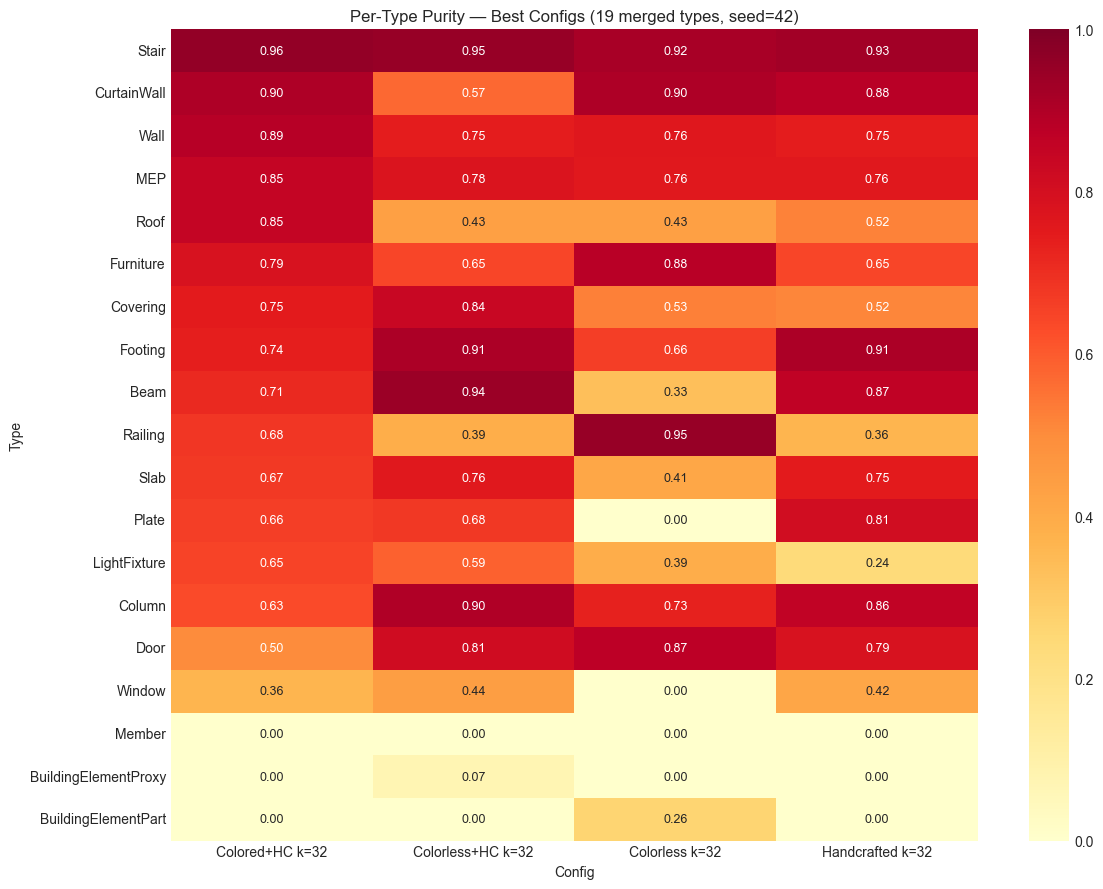

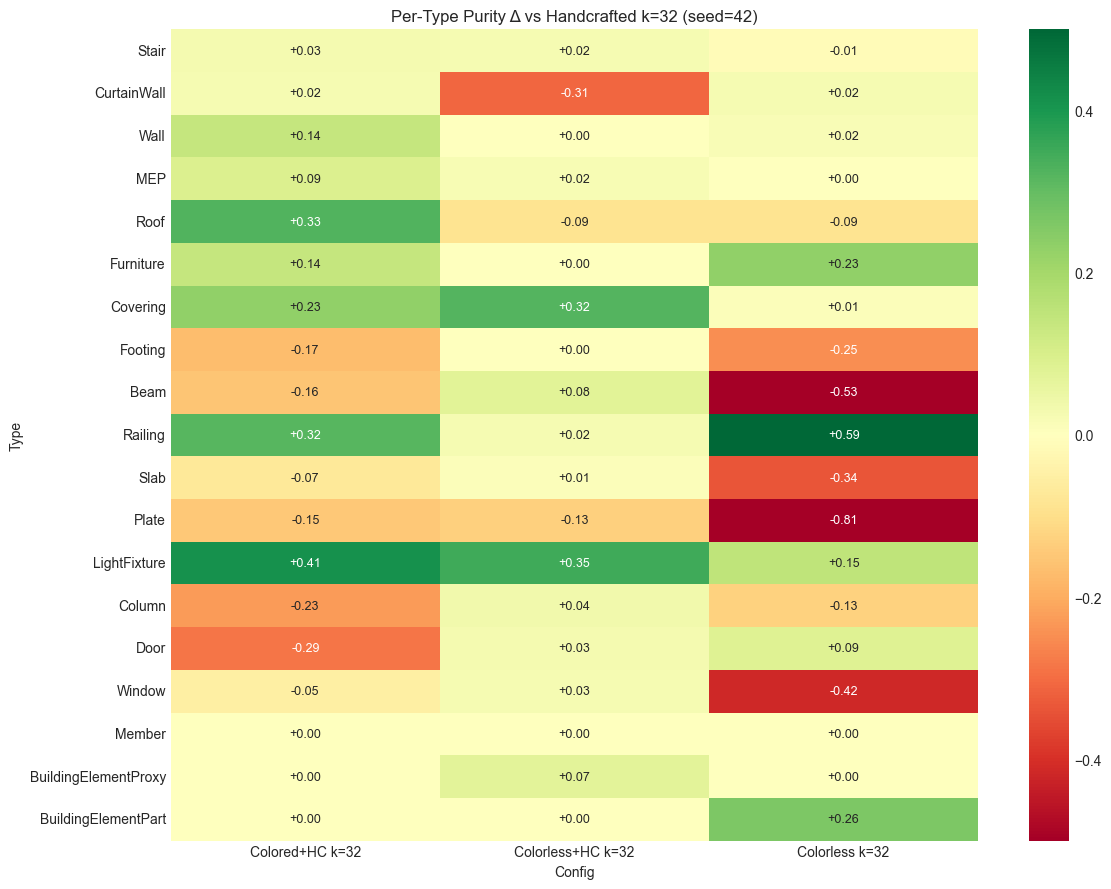

In [13]:
# Per-type purity comparison: top configs + handcrafted
all_merged = sorted(set(ifc_types))
tp_results = {}
for label, d, k, pur, X in plot_configs:
    X_sc = RobustScaler().fit_transform(X)
    lab = MiniBatchKMeans(k, batch_size=1024, n_init='auto', random_state=42).fit_predict(X_sc)
    tp_results[f'{label} k={k}'] = per_type_purity(lab, ifc_types)

tp_names = list(tp_results.keys())
df_tp = pd.DataFrame({n: [tp_results[n].get(t, 0) for t in all_merged]
                       for n in tp_names}, index=all_merged)
df_tp.index = df_tp.index.str.replace('Ifc', '')
df_tp = df_tp.sort_values(tp_names[0], ascending=False)

# Absolute purity
fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(df_tp, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax, vmin=0, vmax=1,
            annot_kws={'size': 9})
ax.set_title('Per-Type Purity — Best Configs (19 merged types, seed=42)', fontsize=12)
ax.set_xlabel('Config'); ax.set_ylabel('Type')
plt.tight_layout(); plt.show()

# Delta vs handcrafted
hc_col = tp_names[-1]  # Handcrafted is last
df_delta = pd.DataFrame(index=df_tp.index)
for n in tp_names[:-1]:
    df_delta[n] = df_tp[n] - df_tp[hc_col]

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(df_delta, annot=True, fmt='+.02f', cmap='RdYlGn', vmin=-0.5, vmax=0.5,
            center=0, ax=ax, annot_kws={'size': 9})
ax.set_title(f'Per-Type Purity Δ vs {hc_col} (seed=42)', fontsize=12)
ax.set_xlabel('Config'); ax.set_ylabel('Type')
plt.tight_layout(); plt.show()

## 5. HDBSCAN Clustering

Density-based clustering — no need to specify k. Sweep over PCA dimensions and `min_cluster_size`.

In [50]:
import hdbscan
from sklearn.neighbors import KNeighborsClassifier

MIN_CLUSTER_SIZES = [ 15, 25]

def reassign_noise(X, labels, k=3):
    """Assign noise points (-1) via k-NN majority vote on assigned neighbors."""
    lab = labels.copy()
    noise = lab == -1
    if noise.any() and (~noise).any():
        knn = KNeighborsClassifier(n_neighbors=min(k, (~noise).sum()), weights='distance')
        knn.fit(X[~noise], lab[~noise])
        lab[noise] = knn.predict(X[noise])
    return lab

def eval_hdbscan(X, labels, min_cs, scale=True):
    if scale:
        X = RobustScaler().fit_transform(X)
    clusterer = hdbscan.HDBSCAN(min_cluster_size=min_cs, core_dist_n_jobs=-1)
    raw_lab = clusterer.fit_predict(X)
    n_clusters = len(set(raw_lab)) - (1 if -1 in raw_lab else 0)
    orig_noise = (raw_lab == -1).sum()
    orig_noise_frac = orig_noise / len(raw_lab)
    # Reassign noise via 10-NN voting
    lab = reassign_noise(X, raw_lab, k=10)
    if n_clusters < 2:
        return {'purity': (0.0, 0.0), 'n_clusters': n_clusters,
                'orig_noise_frac': orig_noise_frac, 'labels': lab, 'labels_raw': raw_lab}
    pur = compute_purity(lab, labels)
    return {'purity': (pur, 0.0), 'n_clusters': n_clusters,
            'orig_noise_frac': orig_noise_frac, 'labels': lab, 'labels_raw': raw_lab}

# Sweep: PCA dims × min_cluster_size for DINO only
hdb_variants = [
    ('Colored', pca_colored),
    ('Colorless', pca_colorless),
]

hdb_results = {}
for var_name, pca_dict in hdb_variants:
    for d in all_dims:
        for mcs in MIN_CLUSTER_SIZES:
            res = eval_hdbscan(pca_dict[d], ifc_types, mcs)
            key = (var_name, d, mcs)
            hdb_results[key] = res
            print(f'  {var_name} PCA-{d:>4} mcs={mcs:>3}  '
                  f'purity={res["purity"][0]:.3f}  k={res["n_clusters"]:>3}  '
                  f'orig_noise={res["orig_noise_frac"]:.1%}')

# Handcrafted baseline
for mcs in MIN_CLUSTER_SIZES:
    res = eval_hdbscan(X_handcrafted, ifc_types, mcs)
    hdb_results[('Handcrafted', 9, mcs)] = res
    print(f'  Handcrafted mcs={mcs:>3}  purity={res["purity"][0]:.3f}  '
          f'k={res["n_clusters"]:>3}  orig_noise={res["orig_noise_frac"]:.1%}')

  Colored PCA-   2 mcs= 15  purity=0.401  k= 15  orig_noise=48.9%
  Colored PCA-   2 mcs= 25  purity=0.212  k=  2  orig_noise=0.0%
  Colored PCA-   4 mcs= 15  purity=0.407  k= 16  orig_noise=57.9%
  Colored PCA-   4 mcs= 25  purity=0.247  k=  3  orig_noise=9.8%
  Colored PCA-   8 mcs= 15  purity=0.512  k= 20  orig_noise=63.4%
  Colored PCA-   8 mcs= 25  purity=0.431  k= 10  orig_noise=60.1%
  Colored PCA-  16 mcs= 15  purity=0.524  k= 18  orig_noise=59.7%
  Colored PCA-  16 mcs= 25  purity=0.158  k=  2  orig_noise=8.0%
  Colored PCA-  32 mcs= 15  purity=0.444  k= 17  orig_noise=68.0%
  Colored PCA-  32 mcs= 25  purity=0.158  k=  2  orig_noise=14.0%
  Colored PCA-1024 mcs= 15  purity=0.419  k= 13  orig_noise=44.3%
  Colored PCA-1024 mcs= 25  purity=0.383  k=  7  orig_noise=71.9%
  Colorless PCA-   2 mcs= 15  purity=0.234  k=  4  orig_noise=7.4%
  Colorless PCA-   2 mcs= 25  purity=0.211  k=  2  orig_noise=4.9%
  Colorless PCA-   4 mcs= 15  purity=0.408  k= 16  orig_noise=58.8%
  Colorle

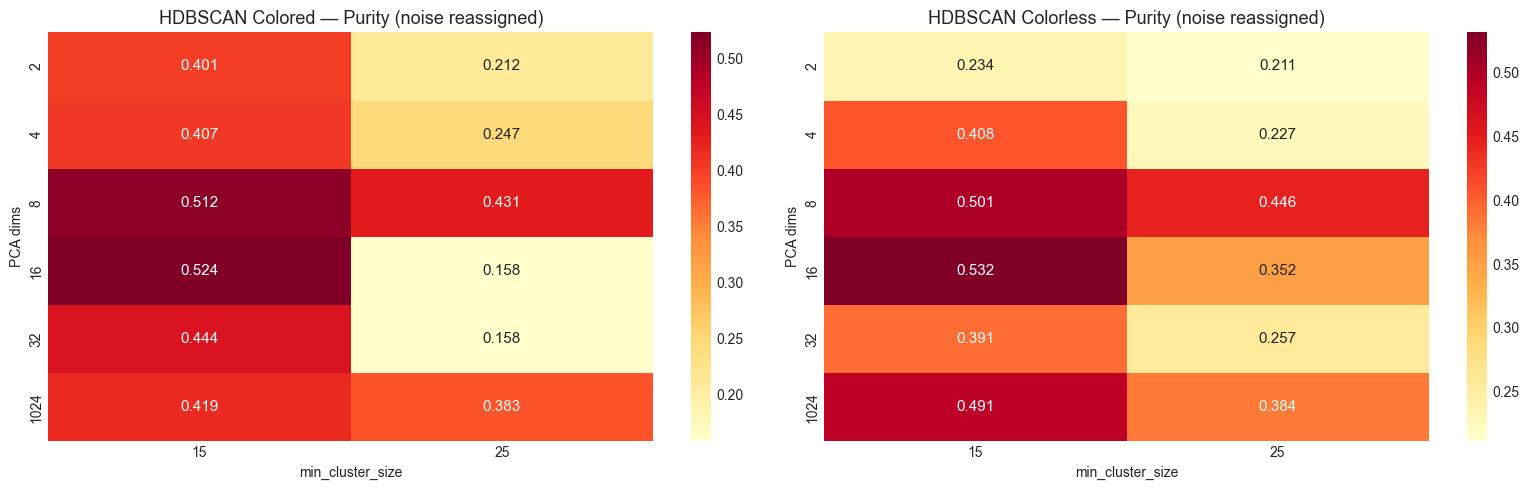

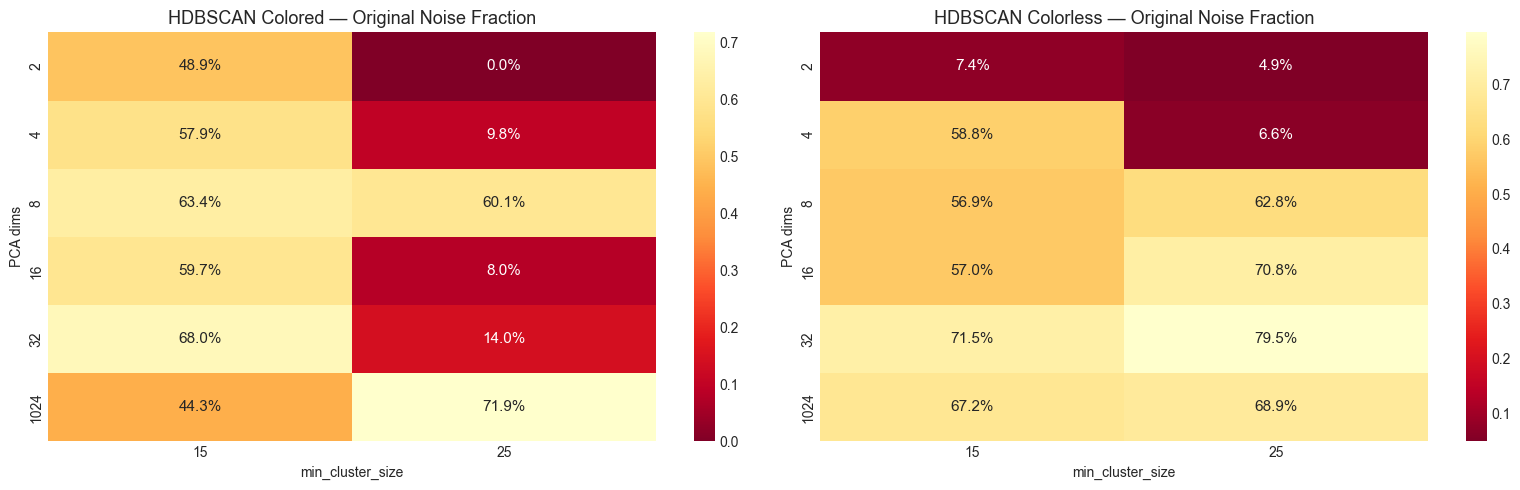

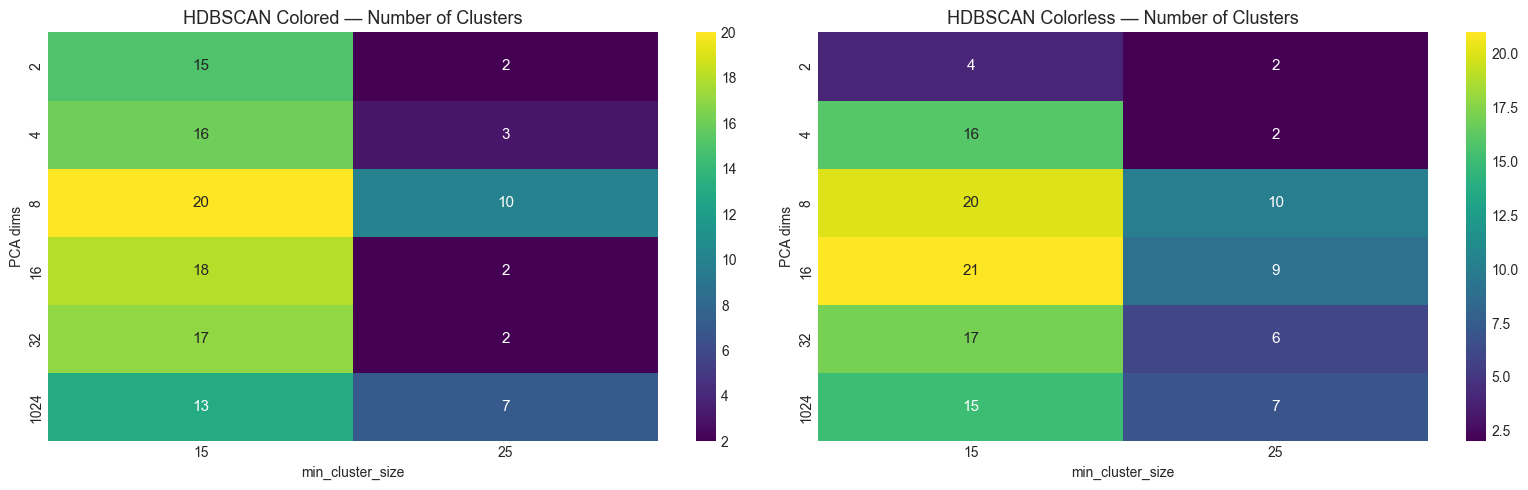

In [45]:
# HDBSCAN Purity heatmaps: PCA dims × min_cluster_size (after noise reassignment)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, var_name in zip(axes, ['Colored', 'Colorless']):
    grid = np.zeros((len(all_dims), len(MIN_CLUSTER_SIZES)))
    for i, d in enumerate(all_dims):
        for j, mcs in enumerate(MIN_CLUSTER_SIZES):
            grid[i, j] = hdb_results[(var_name, d, mcs)]['purity'][0]
    sns.heatmap(grid, annot=True, fmt='.3f', cmap='YlOrRd',
                xticklabels=[str(m) for m in MIN_CLUSTER_SIZES],
                yticklabels=dim_labels, ax=ax, annot_kws={'size': 11})
    ax.set_xlabel('min_cluster_size'); ax.set_ylabel('PCA dims')
    ax.set_title(f'HDBSCAN {var_name} — Purity (noise reassigned)', fontsize=13)
plt.tight_layout(); plt.show()

# Original noise fraction heatmaps (before reassignment)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, var_name in zip(axes, ['Colored', 'Colorless']):
    grid = np.zeros((len(all_dims), len(MIN_CLUSTER_SIZES)))
    for i, d in enumerate(all_dims):
        for j, mcs in enumerate(MIN_CLUSTER_SIZES):
            grid[i, j] = hdb_results[(var_name, d, mcs)]['orig_noise_frac']
    sns.heatmap(grid, annot=True, fmt='.1%', cmap='YlOrRd_r',
                xticklabels=[str(m) for m in MIN_CLUSTER_SIZES],
                yticklabels=dim_labels, ax=ax, annot_kws={'size': 11})
    ax.set_xlabel('min_cluster_size'); ax.set_ylabel('PCA dims')
    ax.set_title(f'HDBSCAN {var_name} — Original Noise Fraction', fontsize=13)
plt.tight_layout(); plt.show()

# Number of clusters heatmaps
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, var_name in zip(axes, ['Colored', 'Colorless']):
    grid = np.zeros((len(all_dims), len(MIN_CLUSTER_SIZES)))
    for i, d in enumerate(all_dims):
        for j, mcs in enumerate(MIN_CLUSTER_SIZES):
            grid[i, j] = hdb_results[(var_name, d, mcs)]['n_clusters']
    sns.heatmap(grid, annot=True, fmt='.0f', cmap='viridis',
                xticklabels=[str(m) for m in MIN_CLUSTER_SIZES],
                yticklabels=dim_labels, ax=ax, annot_kws={'size': 11})
    ax.set_xlabel('min_cluster_size'); ax.set_ylabel('PCA dims')
    ax.set_title(f'HDBSCAN {var_name} — Number of Clusters', fontsize=13)
plt.tight_layout(); plt.show()

In [46]:
# HDBSCAN + Handcrafted fusion sweep
hdb_fused_results = {}
for var_name, pca_dict in hdb_variants:
    for d in all_dims:
        X_fused = np.hstack([pca_dict[d], X_handcrafted])
        for mcs in MIN_CLUSTER_SIZES:
            res = eval_hdbscan(X_fused, ifc_types, mcs)
            key = (var_name + '+HC', d, mcs)
            hdb_fused_results[key] = res
            print(f'  {var_name}+HC PCA-{d:>4} mcs={mcs:>3}  '
                  f'purity={res["purity"][0]:.3f}  k={res["n_clusters"]:>3}  '
                  f'orig_noise={res["orig_noise_frac"]:.1%} ')

  Colored+HC PCA-   2 mcs= 15  purity=0.544  k= 17  orig_noise=57.8% 
  Colored+HC PCA-   2 mcs= 25  purity=0.427  k=  9  orig_noise=55.0% 
  Colored+HC PCA-   4 mcs= 15  purity=0.503  k= 16  orig_noise=60.3% 
  Colored+HC PCA-   4 mcs= 25  purity=0.391  k=  6  orig_noise=55.6% 
  Colored+HC PCA-   8 mcs= 15  purity=0.585  k= 20  orig_noise=59.3% 
  Colored+HC PCA-   8 mcs= 25  purity=0.430  k=  9  orig_noise=62.1% 
  Colored+HC PCA-  16 mcs= 15  purity=0.586  k= 19  orig_noise=62.9% 
  Colored+HC PCA-  16 mcs= 25  purity=0.437  k= 10  orig_noise=70.7% 
  Colored+HC PCA-  32 mcs= 15  purity=0.428  k= 16  orig_noise=72.4% 
  Colored+HC PCA-  32 mcs= 25  purity=0.337  k=  9  orig_noise=75.1% 
  Colored+HC PCA-1024 mcs= 15  purity=0.420  k= 13  orig_noise=44.8% 
  Colored+HC PCA-1024 mcs= 25  purity=0.352  k=  6  orig_noise=67.7% 
  Colorless+HC PCA-   2 mcs= 15  purity=0.580  k= 21  orig_noise=57.6% 
  Colorless+HC PCA-   2 mcs= 25  purity=0.405  k=  8  orig_noise=52.6% 
  Colorless+HC P

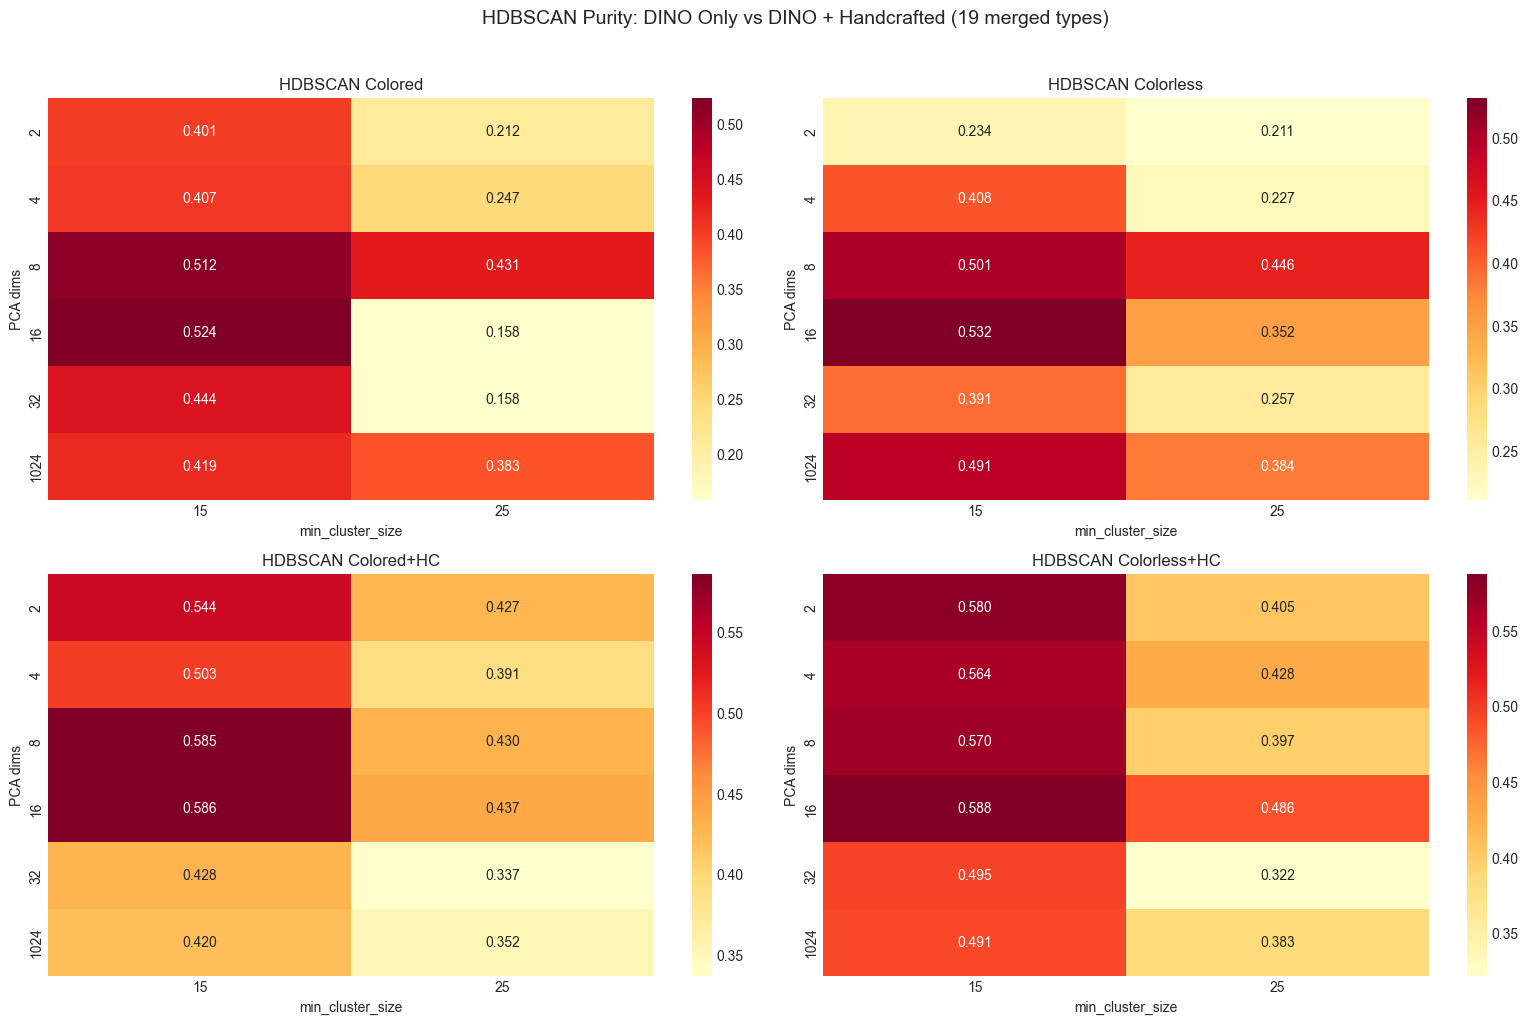

In [47]:
# HDBSCAN fusion heatmaps: purity (4-panel: DINO-only vs DINO+HC)
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
panels = [
    ('Colored', hdb_results), ('Colorless', hdb_results),
    ('Colored+HC', hdb_fused_results), ('Colorless+HC', hdb_fused_results),
]
for ax, (var_name, results) in zip(axes.flat, panels):
    grid = np.zeros((len(all_dims), len(MIN_CLUSTER_SIZES)))
    for i, d in enumerate(all_dims):
        for j, mcs in enumerate(MIN_CLUSTER_SIZES):
            grid[i, j] = results[(var_name, d, mcs)]['purity'][0]
    sns.heatmap(grid, annot=True, fmt='.3f', cmap='YlOrRd',
                xticklabels=[str(m) for m in MIN_CLUSTER_SIZES],
                yticklabels=dim_labels, ax=ax, annot_kws={'size': 10})
    ax.set_xlabel('min_cluster_size'); ax.set_ylabel('PCA dims')
    ax.set_title(f'HDBSCAN {var_name}', fontsize=12)
plt.suptitle('HDBSCAN Purity: DINO Only vs DINO + Handcrafted (19 merged types)', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

Best HDBSCAN: Handcrafted PCA-9 mcs=15 → purity=0.592, k=22, orig_noise=59.5%
Handcrafted HDBSCAN: mcs=15 → purity=0.592, k=22, orig_noise=59.5%


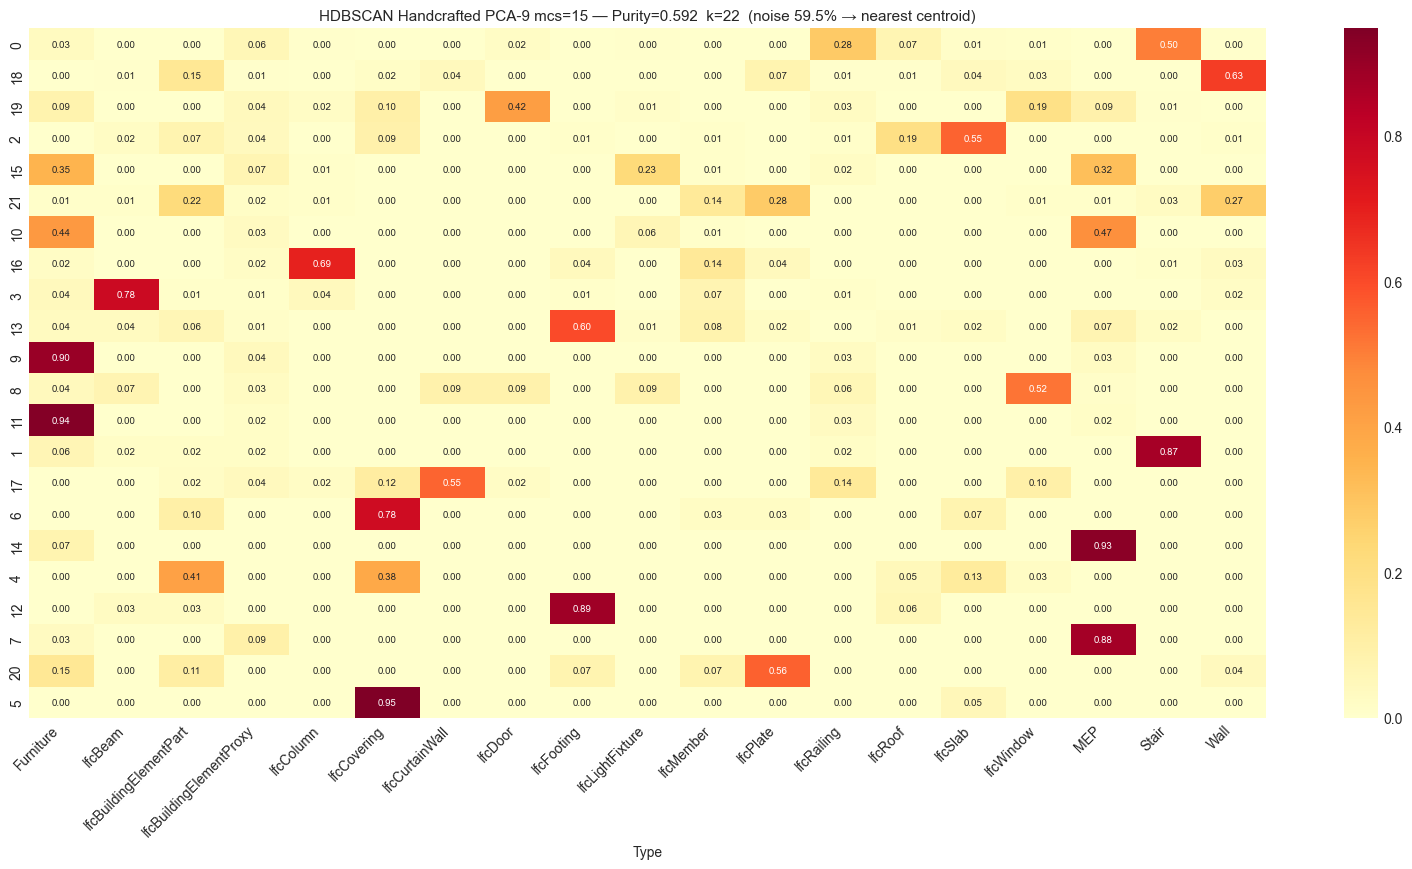

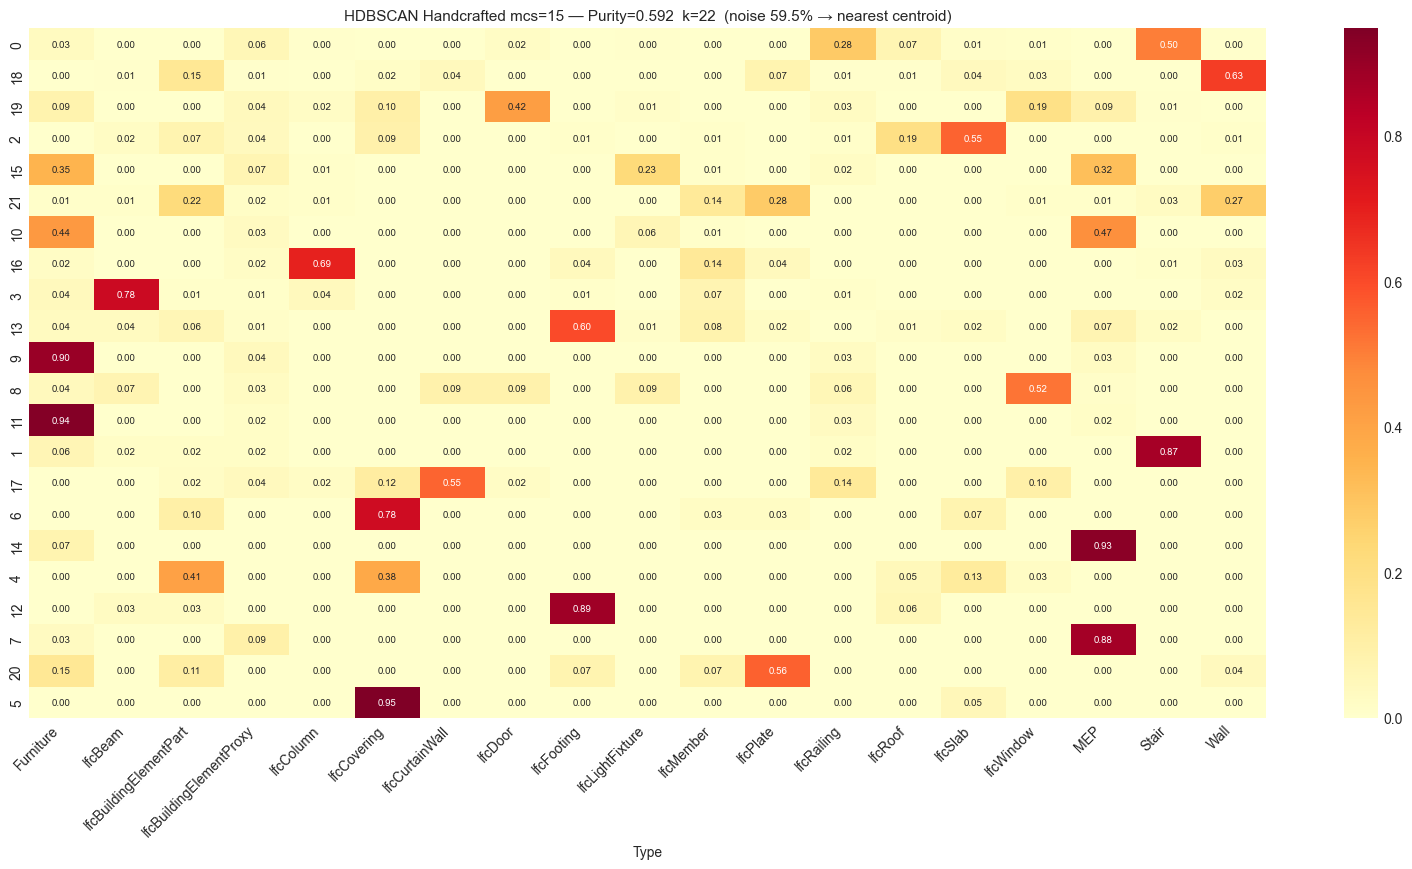

In [48]:
# Best HDBSCAN config — cluster-type heatmap
all_hdb = {}
for key, res in hdb_results.items():
    all_hdb[key] = res
for key, res in hdb_fused_results.items():
    all_hdb[key] = res
for mcs in MIN_CLUSTER_SIZES:
    all_hdb[('Handcrafted', 9, mcs)] = hdb_results[('Handcrafted', 9, mcs)]

# Find best by purity (with at least 2 clusters)
best_hdb = max(
    ((k, v) for k, v in all_hdb.items() if v['n_clusters'] >= 2),
    key=lambda x: x[1]['purity'][0]
)
bk, bv = best_hdb
print(f'Best HDBSCAN: {bk[0]} PCA-{bk[1]} mcs={bk[2]} → '
      f'purity={bv["purity"][0]:.3f}, k={bv["n_clusters"]}, orig_noise={bv["orig_noise_frac"]:.1%}')

best_hc_hdb = max(
    ((k, v) for k, v in all_hdb.items() if k[0] == 'Handcrafted' and v['n_clusters'] >= 2),
    key=lambda x: x[1]['purity'][0]
)
hck, hcv = best_hc_hdb
print(f'Handcrafted HDBSCAN: mcs={hck[2]} → purity={hcv["purity"][0]:.3f}, '
      f'k={hcv["n_clusters"]}, orig_noise={hcv["orig_noise_frac"]:.1%}')

# Plot best config cluster-type heatmaps (all points assigned)
for label, key, res in [
    (f'{bk[0]} PCA-{bk[1]} mcs={bk[2]}', bk, bv),
    (f'Handcrafted mcs={hck[2]}', hck, hcv),
]:
    lab = res['labels']  # all points assigned (noise → nearest centroid)
    ct = pd.crosstab(pd.Series(lab, name='Cluster'),
                     pd.Series(ifc_types, name='Type'), normalize='index')
    ct = ct.reindex(pd.Series(lab).value_counts().index)
    n_cl = res['n_clusters']

    fig, ax = plt.subplots(figsize=(16, max(8, n_cl * 0.4)))
    sns.heatmap(ct, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax,
                annot_kws={'size': 6 if n_cl > 24 else 7})
    ax.set_title(f'HDBSCAN {label} — Purity={res["purity"][0]:.3f}  k={n_cl}  '
                 f'(noise {res["orig_noise_frac"]:.1%} → nearest centroid)', fontsize=11)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    plt.tight_layout(); plt.show()